# Random Forest from Scratch 
### Bootstrap, feature bagging, OOB error, voting

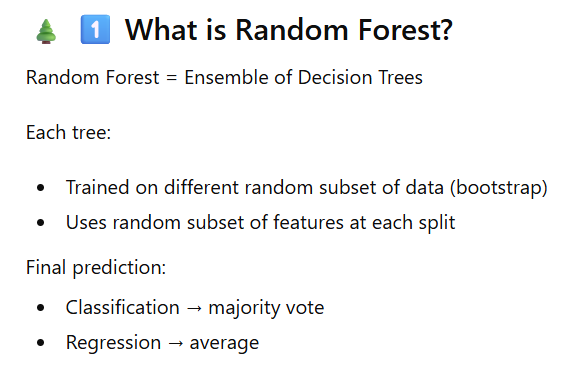

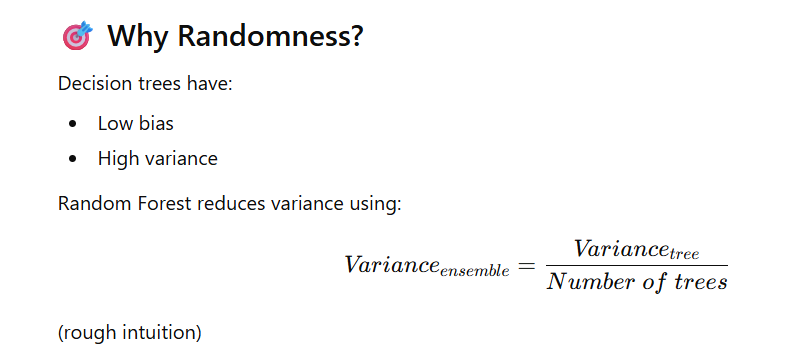

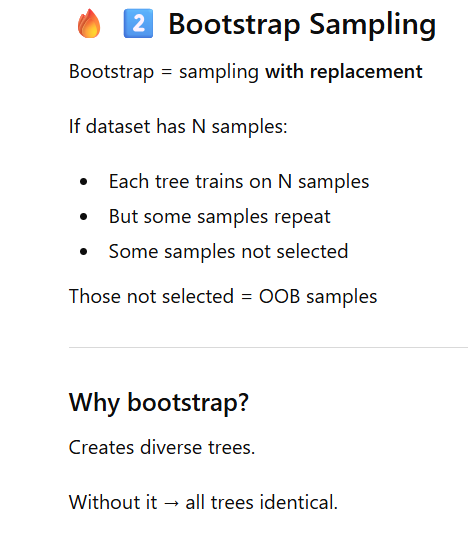

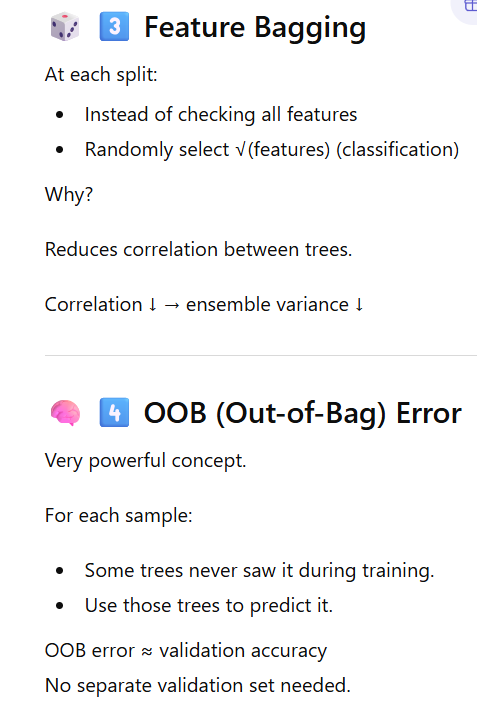

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from collections import Counter

In [4]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # for leaf nodes

class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

    def gini(self, y):
        classes = np.unique(y)
        impurity = 1
        for cls in classes:
            p = np.sum(y == cls) / len(y)
            impurity -= p ** 2
        return impurity
    
    def best_split(self, X, y):
        best_feature, best_threshold = None, None
        best_impurity = float("inf")

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_idx = X[:, feature] <= threshold
                right_idx = X[:, feature] > threshold

                if len(y[left_idx]) == 0 or len(y[right_idx]) == 0:
                    continue

                left_impurity = self.gini(y[left_idx])
                right_impurity = self.gini(y[right_idx])

                weighted_impurity = (
                    len(y[left_idx]) / len(y) * left_impurity + 
                    len(y[right_idx]) / len(y) * right_impurity
                )

                if weighted_impurity < best_impurity:
                    best_impurity = weighted_impurity
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold
    
    def build_tree(self, X, y, depth=0):
        if (depth >= self.max_depth or len(np.unique(y)) == 1 or len(y) < self.min_samples_split):
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)
        
        feature, threshold = self.best_split(X, y)
        if feature is None:
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)
        
        left_idx = X[:, feature] <= threshold
        right_idx = X[:, feature] > threshold

        left = self.build_tree(X[left_idx], y[left_idx], depth+1)
        right = self.build_tree(X[right_idx], y[right_idx], depth+1)

        return Node(feature, threshold, left, right)
    
    def fit(self, X, y):
        self.tree = self.build_tree(X, y)

    def predict_sample(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self.predict_sample(x, node.left)
        return self.predict_sample(x, node.right)
    
    def predict(self, X):
        return np.array([self.predict_sample(x, self.tree) for x in X])



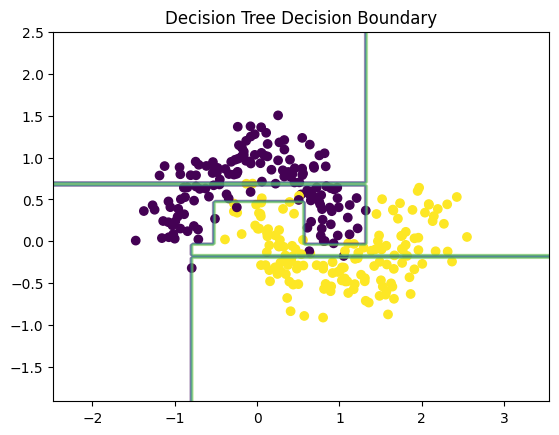

In [5]:
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

tree = DecisionTree(max_depth=5)
tree.fit(X, y)

x_min, x_max = X[:, 0].min()-1, X[:,0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = tree.predict(grid)
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Decision Tree Decision Boundary")
plt.show()


In [6]:
# Random Forest
class RandomForest:
    def __init__(self, n_trees=10, max_depth=5, min_samples_split=2):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, n_samples, replace=True)
        oob_indices = list(set(range(n_samples)) - set(indices))
        return X[indices], y[indices], oob_indices
    
    def fit(self, X, y):
        self.trees = []
        self.oob_indices_list = []

        for _ in range(self.n_trees):
            X_sample, y_sample, oob_indices = self.bootstrap_sample(X, y)

            tree = DecisionTree(
                max_depth = self.max_depth,
                min_samples_split = self.min_samples_split
            )

            tree.fit(X_sample, y_sample)

            self.trees.append(tree)
            self.oob_indices_list.append(oob_indices)

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        tree_preds = np.swapaxes(tree_preds, 0, 1)

        final_preds = []
        for preds in tree_preds:
            final_preds.append(Counter(preds).most_common(1)[0][0])

        return np.array(final_preds)
    
    def oob_score(self, X, y):
        n_samples = X.shape[0]
        votes = [[] for _ in range(n_samples)]

        for tree, oob_indices in zip(self.trees, self.oob_indices_list):
            if len(oob_indices) == 0:
                continue
            preds = tree.predict(X[oob_indices])
            for idx, sample_idx in enumerate(oob_indices):
                votes[sample_idx].append(preds[idx])

        oob_preds = []
        oob_true = []

        for i in range(n_samples):
            if len(votes[i]) > 0:
                oob_preds.append(Counter(votes[i]).most_common(1)[0][0])
                oob_true.append(y[i])

        return np.mean(np.array(oob_preds) == np.array(oob_true))
    


OOB Accuracy:  0.9066666666666666


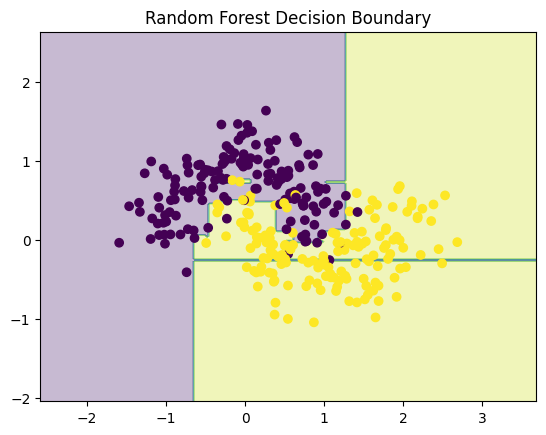

In [7]:
# Dataset

X, y = make_moons(n_samples = 300, noise = 0.25, random_state=42)

rf = RandomForest(n_trees=20, max_depth=6)
rf.fit(X, y)

print("OOB Accuracy: ", rf.oob_score(X, y))

# Decision Boundary
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = rf.predict(grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Random Forest Decision Boundary")
plt.show()

In [1]:
# 
def bootstrap_sample(self, X, y):
    n_samples =  X.shape[0]
    indices = np.random.choice(n_samples, n_samples, replace=True)
    oob_indices = list(set(range(n_samples))-set(indices))
    return X[indices], y[indices], oob_indices

def fit(self, X, y):
    self.trees = []
    self.oob_indices_list = []

    for _ in range(self.n_trees):
        X_sample, y_sample, oob_indices = self.bootstrap_sample(X, y)

        tree = DecisionTree(
            max_depth = self.max_depth,
            min_samples_split= self.min_samples_split
        )

        tree.fit(X_sample, y_sample)
        self.trees.append(tree)
        self.oob_indices_list.append(oob_indices)

def predict(self, X):
    tree_preds = np.array([tree.predict(X) for tree in self.trees])
    tree_preds = np.swapaxes(tree_preds, 0, 1)

    final_preds = []
    for preds in tree_preds:
        final_preds.append(Counter(preds).most_common(1)[0][0])
    return np.array(final_preds)
